## Students 

* Ettore Vissa (2197527)
* Enrica Calabretto (2198447)
* Sara Pasquato (2198446)
* Nicolo' Meneguzzo (*******)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting 
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)

#Feed Forward Neural Networks 
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.model_selection import KFold

from sklearn.preprocessing import StandardScaler

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13

XGBoost version: 3.2.0


## Read and Split the data 

In [2]:
np.random.seed(12345)

dname="./DATA/"
str0="_XGB_26.dat"
fnamex=dname+'x'+str0
fnamey=dname+'y'+str0
x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])

N_train = int(0.75*N)
x_train,y_train = x[:N_train],y[:N_train]
x_val,y_val = x[N_train:],y[N_train:]
print(f"N={N}, N_train={N_train}, L={L}")

N=5000, N_train=3750, L=4


[-31.608 -29.544   6.773   9.554] 0
[46.451 15.318 24.891 15.357] 0
[ 24.771  46.131 -49.161 -39.356] 0
[-20.13   15.641  30.981  37.218] 0
[46.465 22.369 14.248 21.745] 0


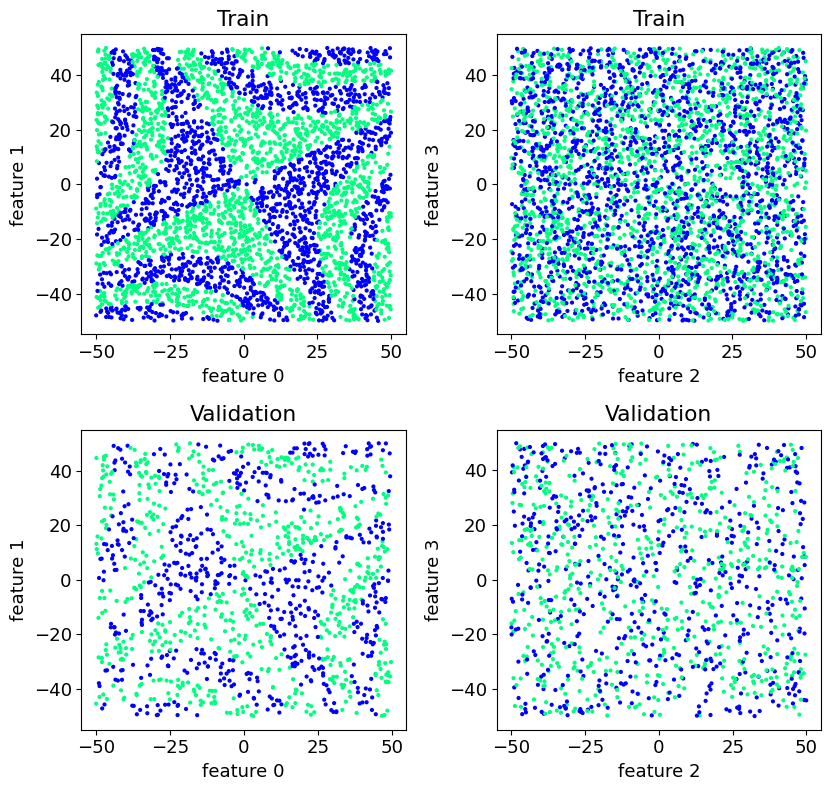

In [8]:
def scat(ax,x,y,i=0,j=1,s=4,title=""):
    # scatter plot of the data in the plane of features i and j
    ax.scatter(x[:,i],x[:,j],s=s,c=y) 
    ax.set_xlabel(f"feature {i}")
    ax.set_ylabel(f"feature {j}")
    ax.set_title(title)

# print the first 5 data points
for n in range(5):
    print(x[n],y[n])

#print feature plots for the training and test sets
fig,AX = plt.subplots(2,2,figsize=(8.5,8.1))
scat(AX[0,0],x_train,y_train,title="Train")
scat(AX[0,1],x_train,y_train,i=2,j=3,title="Train")
scat(AX[1,0],x_val,y_val,title="Validation")
scat(AX[1,1],x_val,y_val,i=2,j=3,title="Validation")
fig.tight_layout()
plt.show()

In [9]:
def classify(clf=GradientBoostingClassifier(),show=False):
    # GradientBoostingClassifier():
    #   n_estimators = 100 (default)
    #   loss function = deviance(default) used in Logistic Regression
    # XGBClassifier()
    #   n_estimators = 100 (default)
    #   max_depth = 3 (default?)
    
    clf.fit(x_train,y_train) # train the model on the training set
    y_hat = clf.predict(x_val) # predict the labels of the test set
    
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_val, y_val)),clf.score(x_val, y_val)))
    S=50 # size of the square grid
    dx = 1
    x_seq=np.arange(-S,S+dx,dx) # sequence of points for the grid
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L)) # grid of points
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] # only the first two features are used for the artificial grid
            q+=1
    y_plot= clf.predict(x_plot) # predict the labels of the grid points

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()
    
    if show:      
        dump_list = clf.get_booster().get_dump() # get the list of trees in the model
        num_trees = len(dump_list)
        print("num_trees=",num_trees)
        
        fig, AX = plt.subplots(2,1,figsize=(12, 5))
        for i in range(min(2,num_trees)):
            ax=AX[i]
            plot_tree(clf, num_trees=i, ax=ax)
        fig.savefig("DATA/tree-classif.png", dpi=400, pad_inches=0.02)   
        plt.show()

## 1. Model complexity, parameters and regularization

In [4]:
gamma=[0, 1]
reg_lambda= [0.001, 1, 10] 
n_estimators=[ 5, 10, 15, 20, 25, 30]
max_depth= [2, 3, 5]

results=[]

for n in n_estimators:
    for depth in max_depth:
        for lam in reg_lambda:
            for gam in gamma:

                model= XGBClassifier( n_estimators= n, max_depth= depth, reg_lambda= lam, 
                                     gamma= gam, objective= 'binary:logistic', seed= 1)

                model.fit(x_train, y_train)
                acc= model.score( x_val, y_val)
                results.append((acc, n, depth, lam, gam))

                print( f'acc={acc:.3f}, n_estn_estimators={n}, depth={depth}, lambda= {lam}, gamma={gam}')

                

acc=0.611, n_estn_estimators=5, depth=2, lambda= 0.001, gamma=0
acc=0.611, n_estn_estimators=5, depth=2, lambda= 0.001, gamma=1
acc=0.611, n_estn_estimators=5, depth=2, lambda= 1, gamma=0
acc=0.611, n_estn_estimators=5, depth=2, lambda= 1, gamma=1
acc=0.578, n_estn_estimators=5, depth=2, lambda= 10, gamma=0
acc=0.578, n_estn_estimators=5, depth=2, lambda= 10, gamma=1
acc=0.686, n_estn_estimators=5, depth=3, lambda= 0.001, gamma=0
acc=0.686, n_estn_estimators=5, depth=3, lambda= 0.001, gamma=1
acc=0.686, n_estn_estimators=5, depth=3, lambda= 1, gamma=0
acc=0.686, n_estn_estimators=5, depth=3, lambda= 1, gamma=1
acc=0.693, n_estn_estimators=5, depth=3, lambda= 10, gamma=0
acc=0.693, n_estn_estimators=5, depth=3, lambda= 10, gamma=1
acc=0.814, n_estn_estimators=5, depth=5, lambda= 0.001, gamma=0
acc=0.814, n_estn_estimators=5, depth=5, lambda= 0.001, gamma=1
acc=0.790, n_estn_estimators=5, depth=5, lambda= 1, gamma=0
acc=0.790, n_estn_estimators=5, depth=5, lambda= 1, gamma=1
acc=0.781, n

In [5]:
results.sort( reverse=True)

best_models_list=[]
print( 'best models:')
for r in results[:5]:
    best_models_list.append(r)
    print( f'acc={r[0]:.3f}, estimators={r[1]}, depth={r[2]}, lambda={r[3]}, gamma= {r[4]}')


best models:
acc=0.893, estimators=30, depth=5, lambda=0.001, gamma= 0
acc=0.890, estimators=25, depth=5, lambda=0.001, gamma= 0
acc=0.887, estimators=20, depth=5, lambda=0.001, gamma= 0
acc=0.886, estimators=30, depth=5, lambda=1, gamma= 1
acc=0.886, estimators=25, depth=5, lambda=1, gamma= 1


              Models with estimators=30, max_depth=5, reg_lambda=0.001, gamma=0 

errors: 10.72%   Accuracy=0.893
shape of x_plot= (10201, 4)


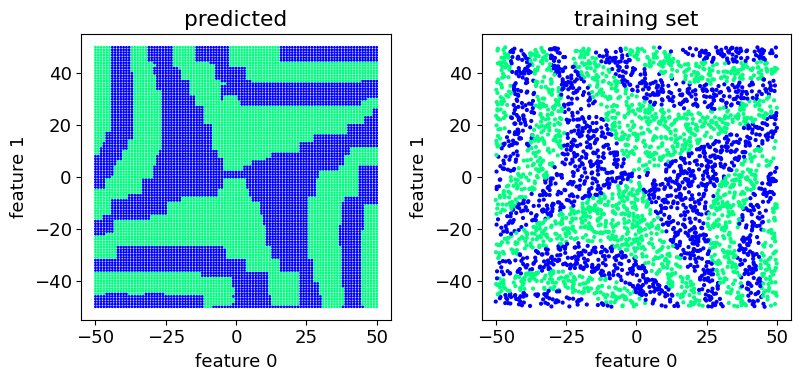

num_trees= 30


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


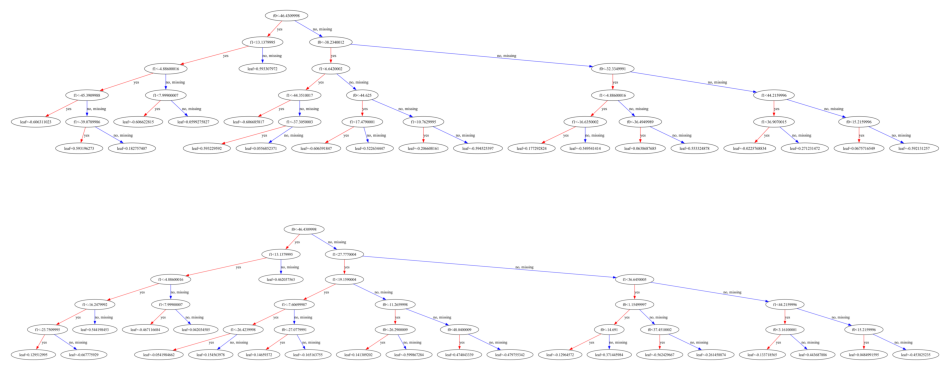

              Models with estimators=25, max_depth=5, reg_lambda=0.001, gamma=0 

errors: 10.96%   Accuracy=0.890
shape of x_plot= (10201, 4)


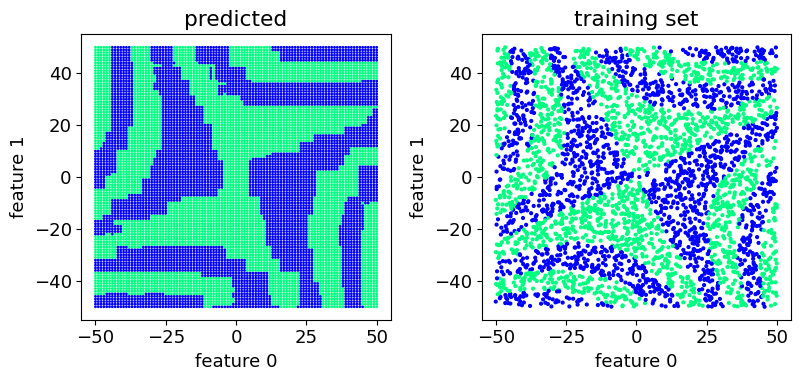

num_trees= 25


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


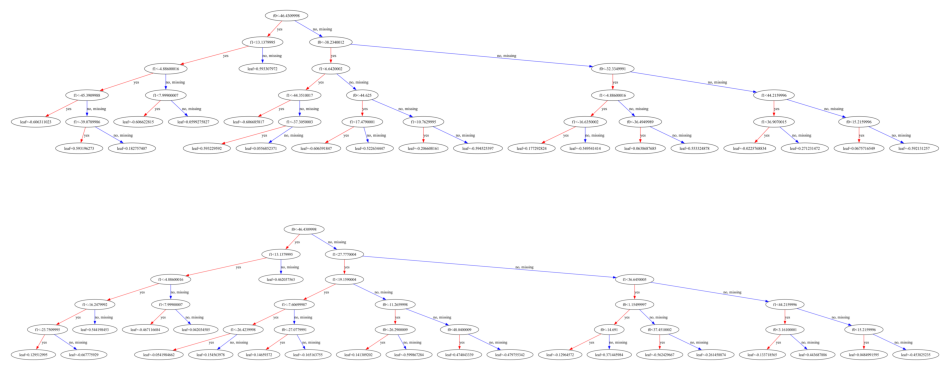

              Models with estimators=20, max_depth=5, reg_lambda=0.001, gamma=0 

errors: 11.28%   Accuracy=0.887
shape of x_plot= (10201, 4)


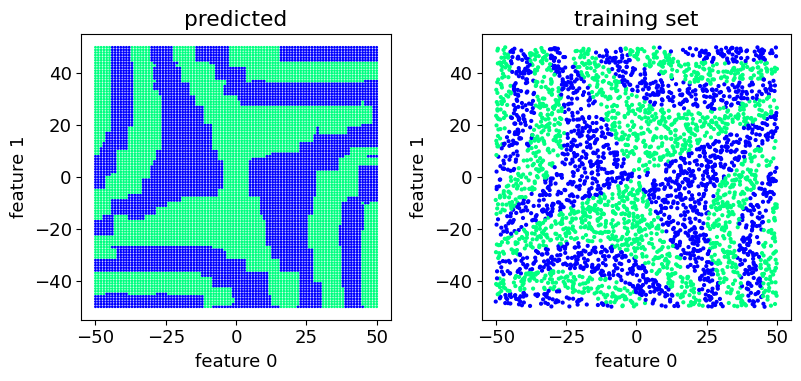

num_trees= 20


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


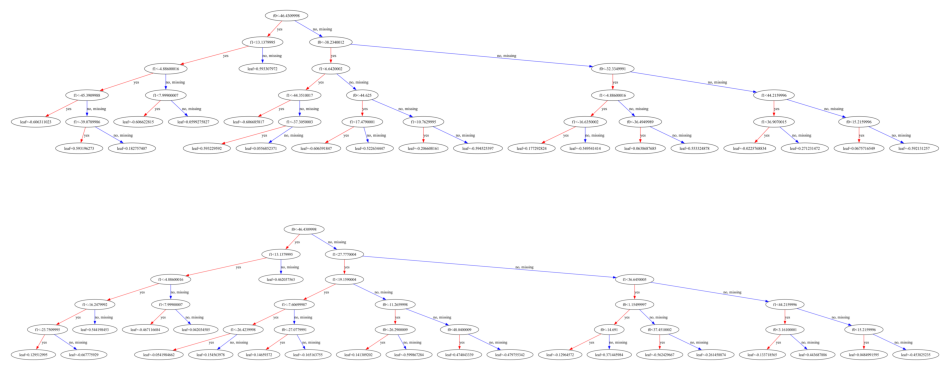

              Models with estimators=30, max_depth=5, reg_lambda=1, gamma=1 

errors: 11.36%   Accuracy=0.886
shape of x_plot= (10201, 4)


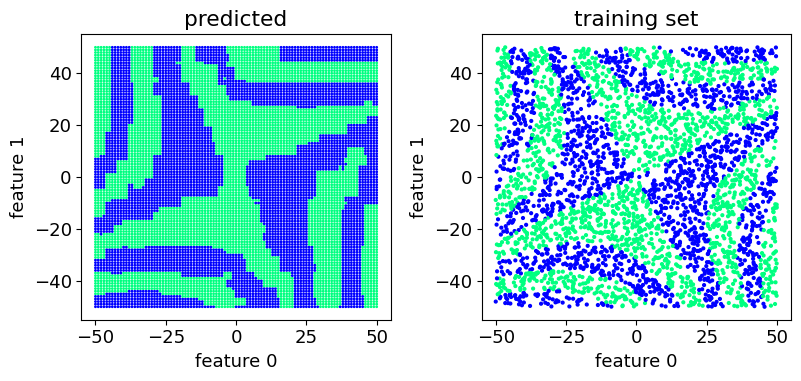

num_trees= 30


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


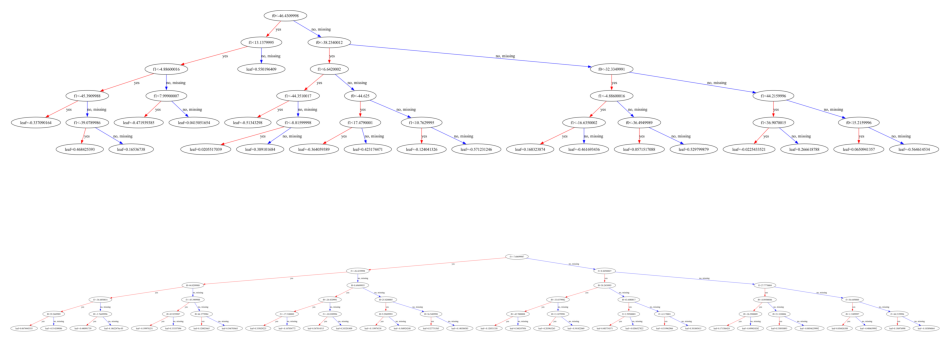

              Models with estimators=25, max_depth=5, reg_lambda=1, gamma=1 

errors: 11.36%   Accuracy=0.886
shape of x_plot= (10201, 4)


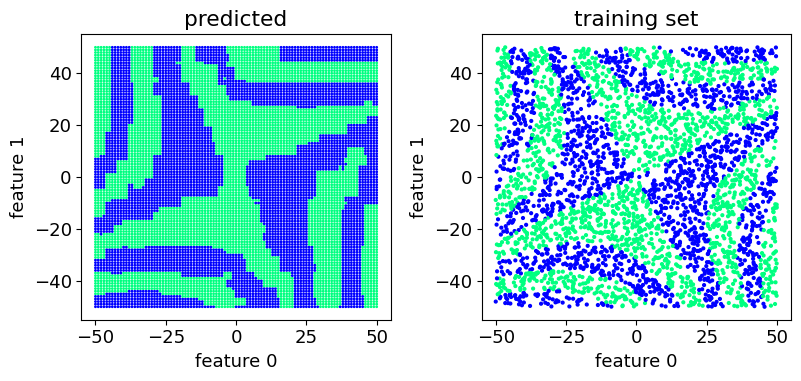

num_trees= 25


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


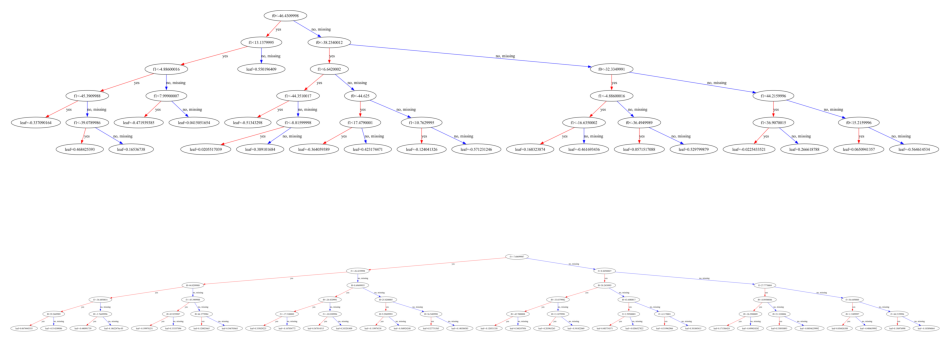

In [10]:
#classify on the best models

for best in best_models_list:

    acc, n_estimators, depth, reg_lambda, gamma = best
    
    best_model= XGBClassifier( n_estimators= n_estimators, max_depth= depth, 
                          reg_lambda= reg_lambda, gamma=gamma, objective='binary:logistic',
                          seed=1)
    print( f'              Models with estimators={n_estimators}, max_depth={depth}, reg_lambda={reg_lambda}, gamma={gamma} \n')
    classify(best_model, show=True)

/var/folders/s1/3907b78x5kz33mqdk788t_3w0000gn/T/ipykernel_57626/1664625755.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


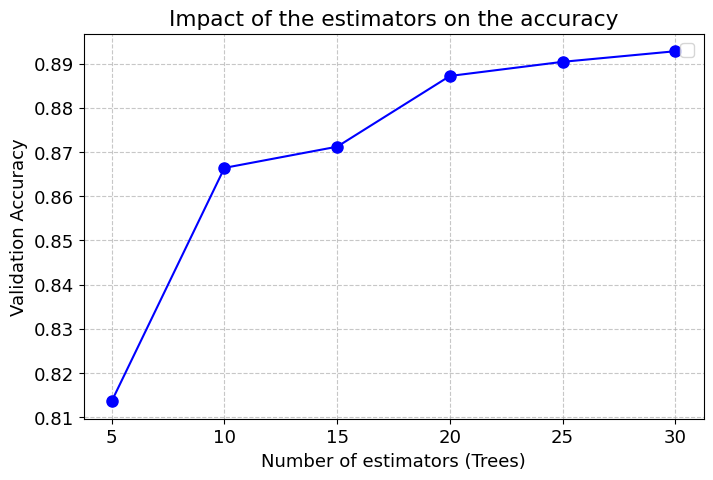

In [6]:
n_trees=[]
accuracies= []

#I fix the tree depth, lambda, and gamma so that I can consistently analyze how only the number of estimators influences the model.
for r in results:
    acc, n, depth, lam, gam= r

    if depth ==5 and lam== 0.001 and gam==0:
        n_trees.append(n)
        accuracies.append(acc)

sorted_indices= np.argsort(n_trees)

n_trees= np.array( n_trees)[sorted_indices]
accuracies=np.array(accuracies)[sorted_indices]

plt.figure(figsize=(8, 5))
plt.plot(n_trees, accuracies, marker='o', linestyle='-', color='blue', markersize=8)
plt.title("Impact of the estimators on the accuracy")
plt.xlabel("Number of estimators (Trees)")
plt.ylabel("Validation Accuracy")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
#plt.savefig('impact_estimators_on_the_accuracy.pdf', dpi=300, bbox_inches='tight')
plt.show()

              Models with estimators=10, max_depth=5, reg_lambda=0.001, gamma=0 

errors: 13.36%   Accuracy=0.866
shape of x_plot= (10201, 4)


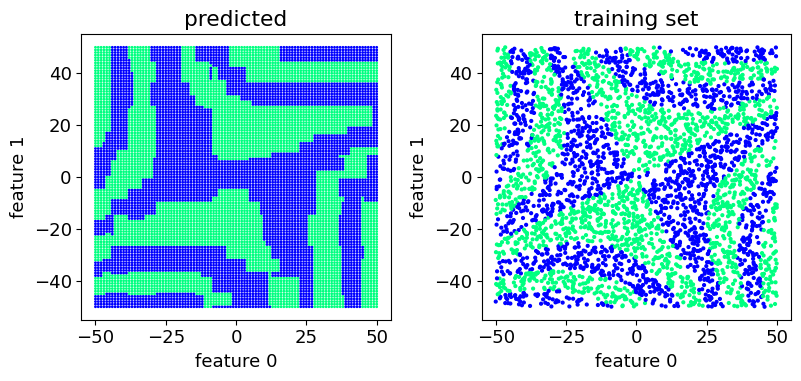

num_trees= 10


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


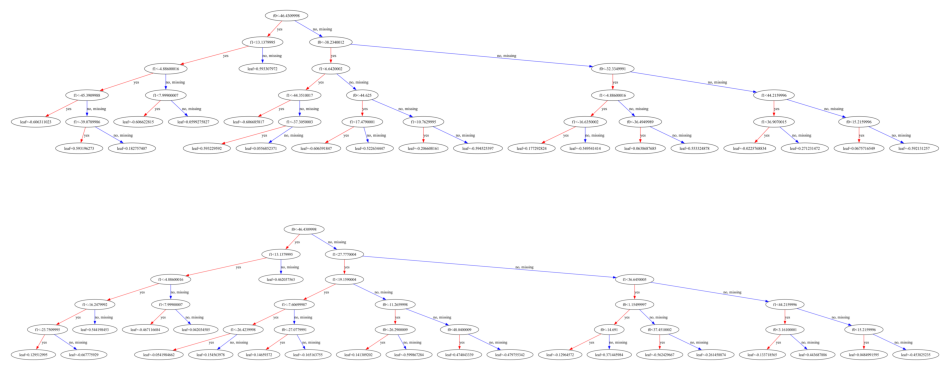

              Models with estimators=10, max_depth=5, reg_lambda=0.001, gamma=1 

errors: 14.16%   Accuracy=0.858
shape of x_plot= (10201, 4)


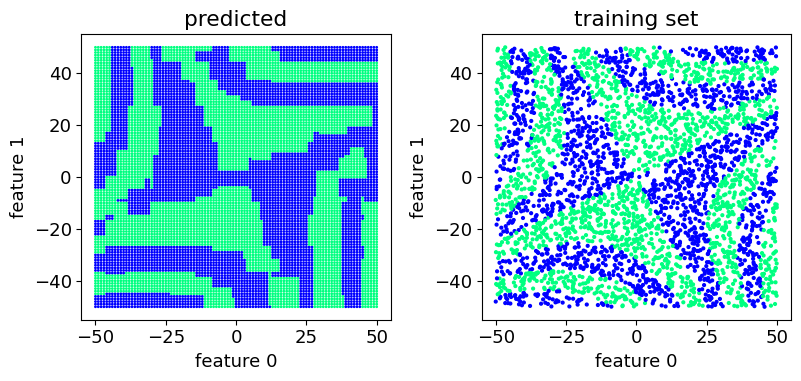

num_trees= 10


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


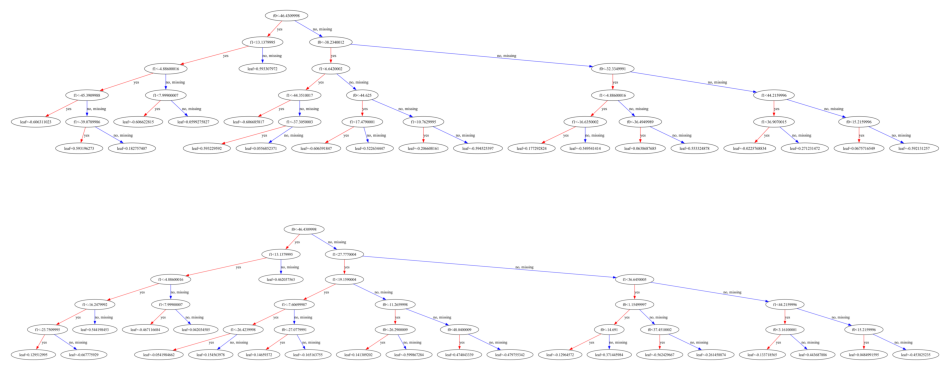

              Models with estimators=10, max_depth=5, reg_lambda=1, gamma=1 

errors: 15.52%   Accuracy=0.845
shape of x_plot= (10201, 4)


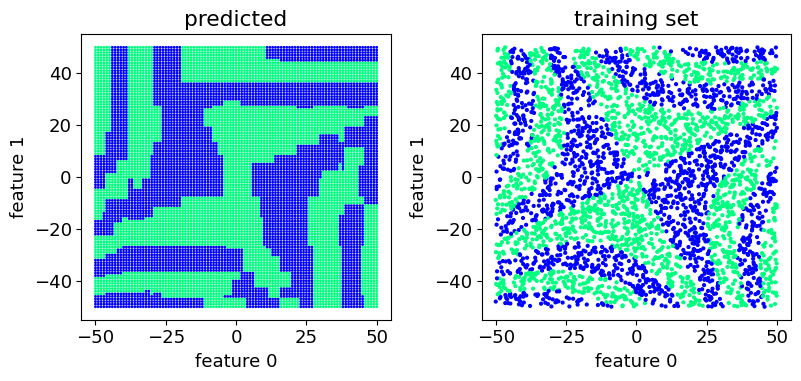

num_trees= 10


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


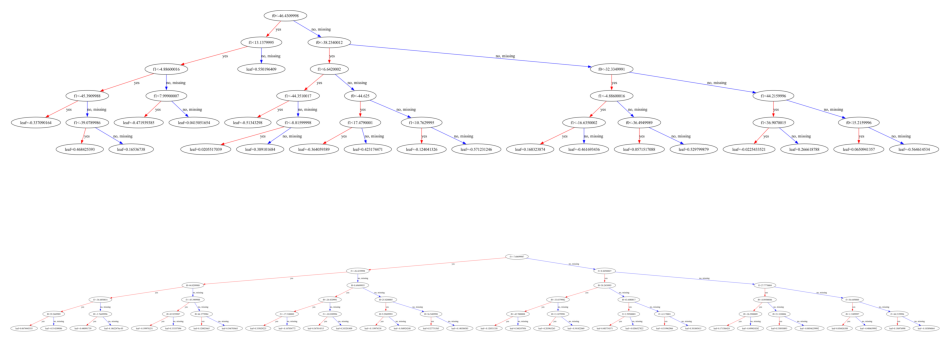

              Models with estimators=10, max_depth=5, reg_lambda=1, gamma=0 

errors: 15.52%   Accuracy=0.845
shape of x_plot= (10201, 4)


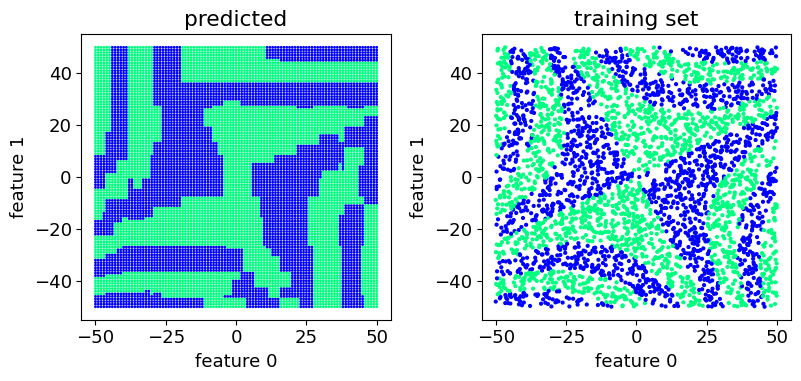

num_trees= 10


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


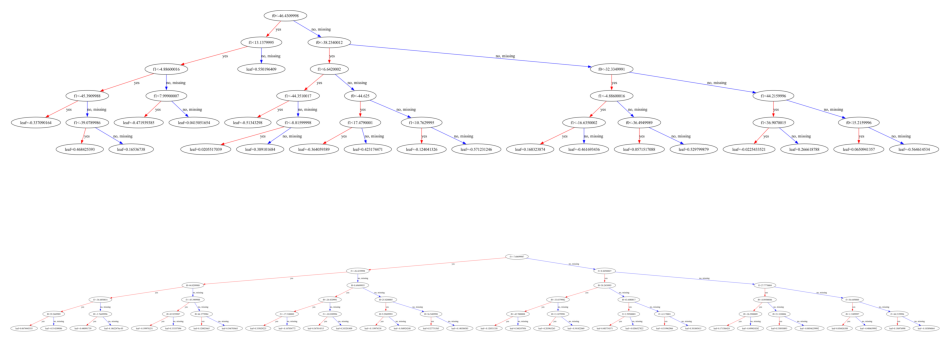

In [11]:
#classify on the trade-off models

for model in results:
    acc, n_estimators, depth, reg_lambda, gamma = model

    if acc>= 0.840:
        if n_estimators<=10 or depth <5:
            model= XGBClassifier( n_estimators= n_estimators, max_depth= depth, 
                          reg_lambda= reg_lambda, gamma=gamma, objective='binary:logistic',
                          seed=1)
            
            print( f'              Models with estimators={n_estimators}, max_depth={depth}, reg_lambda={reg_lambda}, gamma={gamma} \n')
            classify(model, show=True)
        


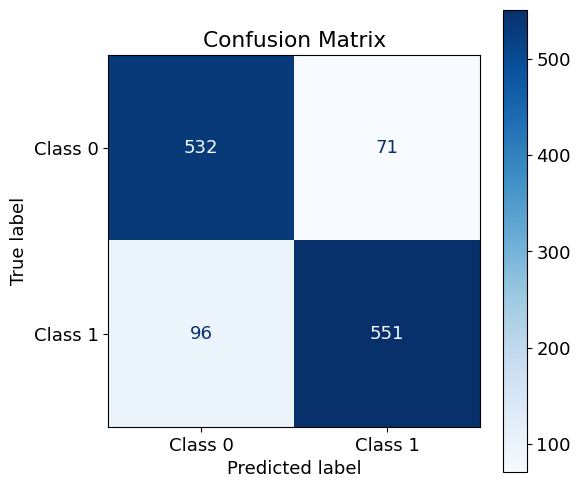

In [12]:
#confusion matrix on the best trade-off model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

tradeoff_model = XGBClassifier(n_estimators=10, max_depth=5, reg_lambda=0.001, gamma=0, seed=1)
tradeoff_model.fit(x_train, y_train)

#prediction on the validation set
y_pred = tradeoff_model.predict(x_val)

cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap='Blues', ax=ax, values_format='d') 

plt.title("Confusion Matrix")
#plt.savefig('confusion_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

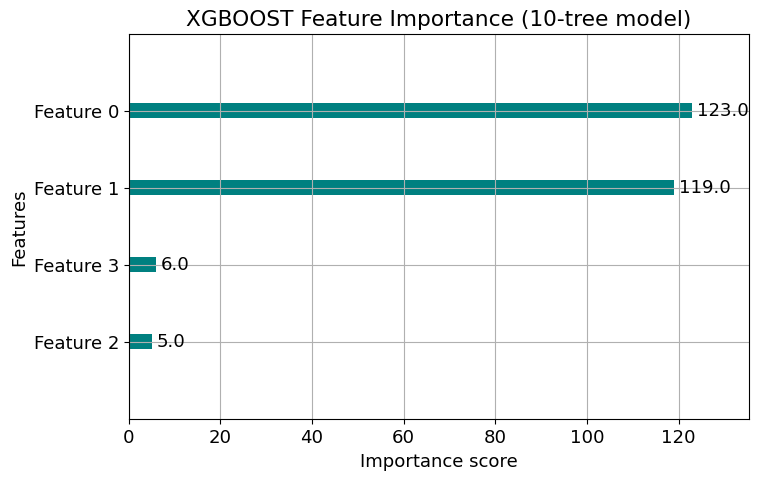

In [13]:
#feature importance 

from xgboost import plot_importance 

booster = tradeoff_model.get_booster()
booster.feature_names = ['Feature 0', 'Feature 1', 'Feature 2', 'Feature 3']

fig,ax = plt.subplots(figsize=(8,5))
plot_importance(booster, ax=ax, importance_type='weight', color= 'teal')
plt.title( 'XGBOOST Feature Importance (10-tree model)')
plt.savefig('feature_importance.pdf', dpi=300, bbox_inches='tight')
plt.show()

To simplify the model, we can reduce the maximum depth and keep the number of estimators as low as possible, while maintaining a validation accuracy above 0.80. In our experiments, all the best models required 30 estimators and depth = 5 to achieve the highest accuracy (0.94–0.95). So, to find models that have an high validation accuracy we search for a number of estimators less then 30, and a max depth less then 5. 

Regularization (L2 lambda or gamma) does not significantly improve validation accuracy in this dataset. Since the dataset is clean and only the first two features are relevant, the model naturally focuses on them. Regularization could be useful in noisier datasets to prevent overfitting, but it is not essential here.

## 2. Dimensionality reduction

Combinazione colonne: (0, 1, 2, 3)
(5000, 4)
errors: 6.64%   Accuracy=0.934
shape of x_plot= (10201, 4)


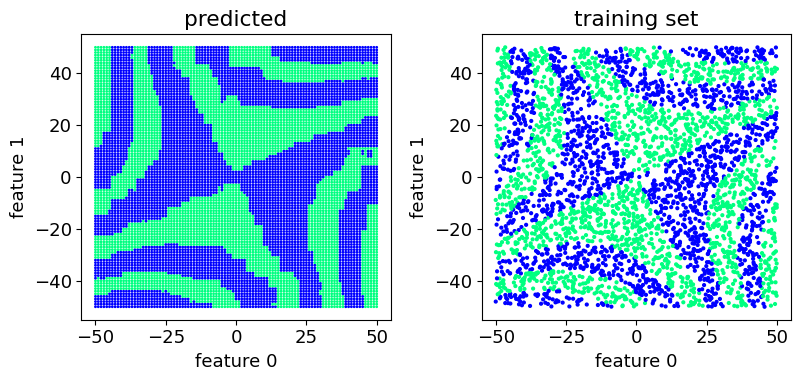

num_trees= 100


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


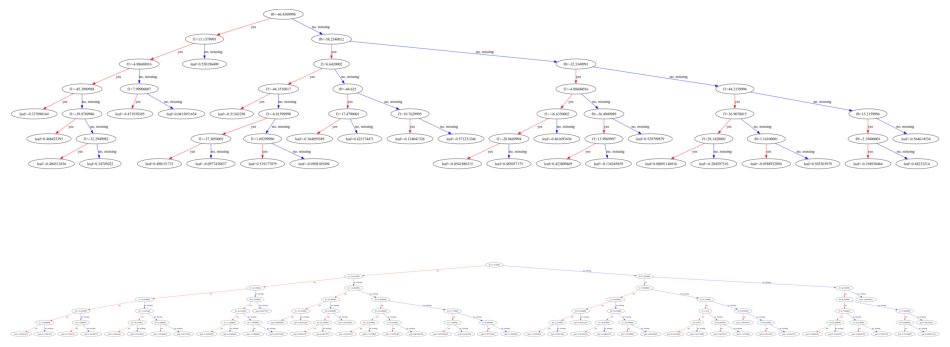

Combinazione colonne: (0, 1)
(5000, 2)
errors: 6.24%   Accuracy=0.938
shape of x_plot= (10201, 2)


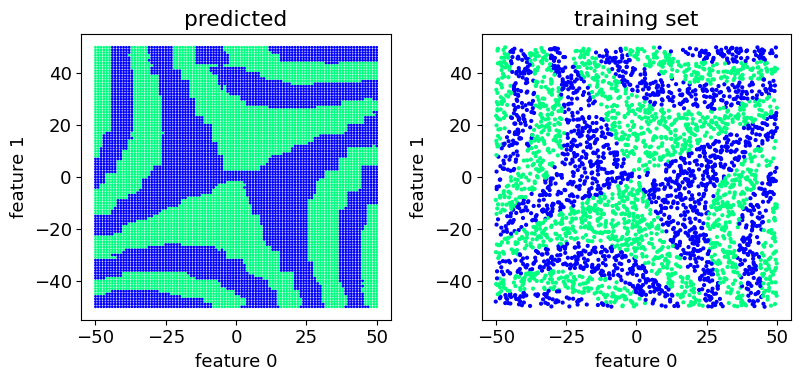

num_trees= 100


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


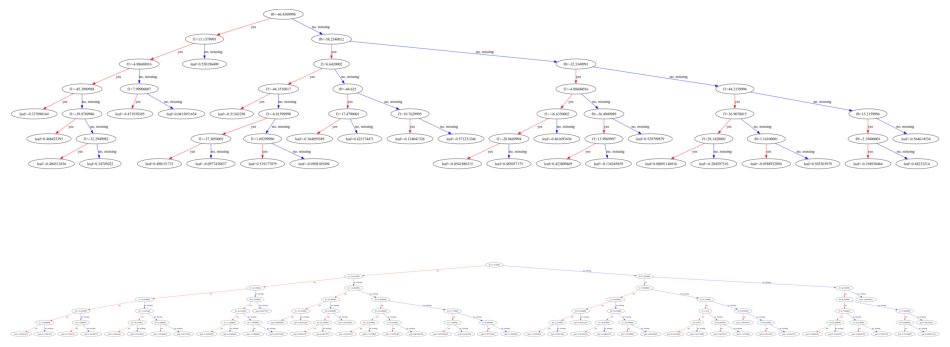

Combinazione colonne: (0, 1, 3)
(5000, 3)
errors: 6.88%   Accuracy=0.931
shape of x_plot= (10201, 3)


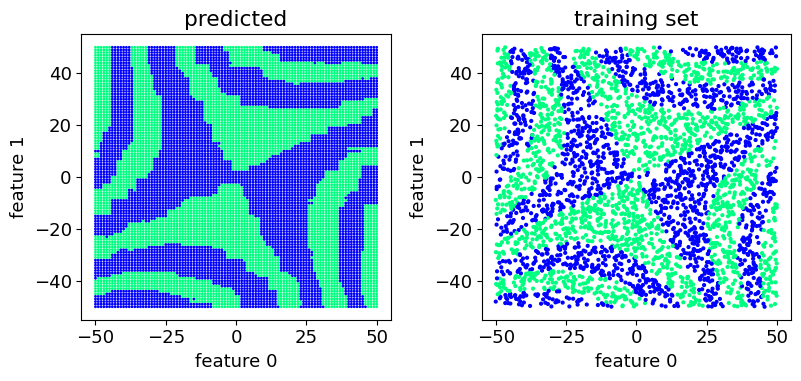

num_trees= 100


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


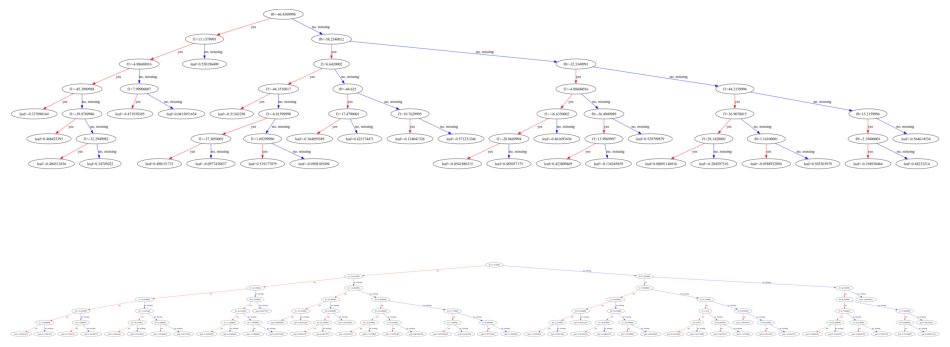

Combinazione colonne: (1, 2)
(5000, 2)
errors: 43.52%   Accuracy=0.565
shape of x_plot= (10201, 2)


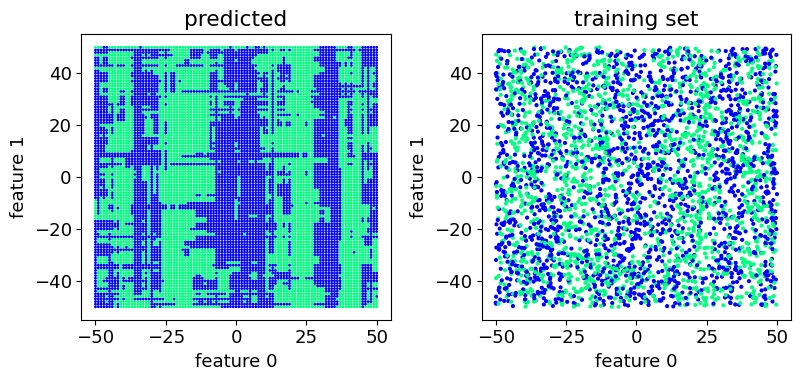

num_trees= 100


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


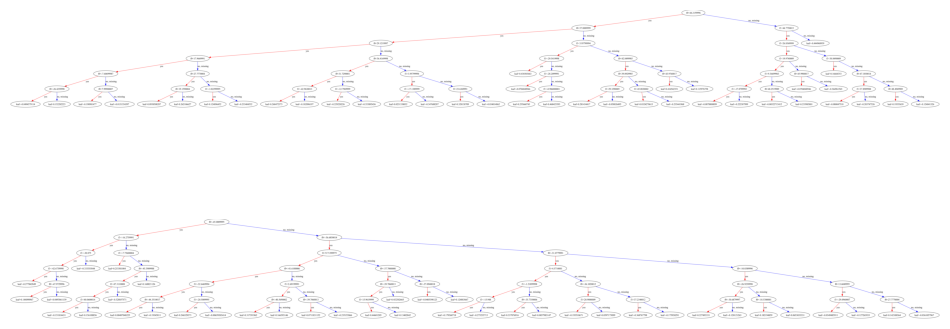

Combinazione colonne: (0, 2, 3)
(5000, 3)
errors: 41.76%   Accuracy=0.582
shape of x_plot= (10201, 3)


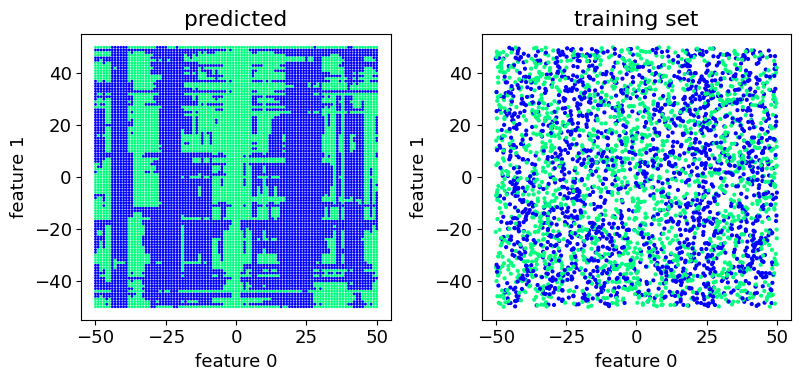

num_trees= 100


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


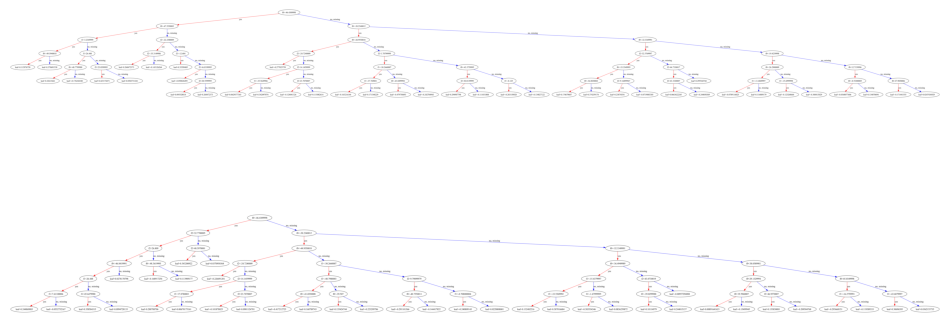

Combinazione colonne: (2, 3)
(5000, 2)
errors: 49.36%   Accuracy=0.506
shape of x_plot= (10201, 2)


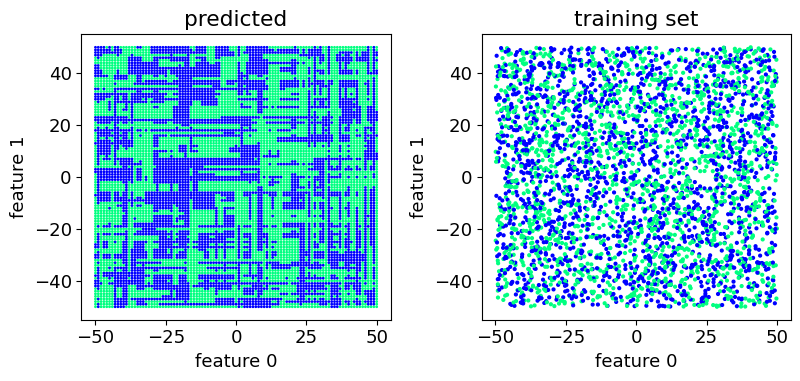

num_trees= 100


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


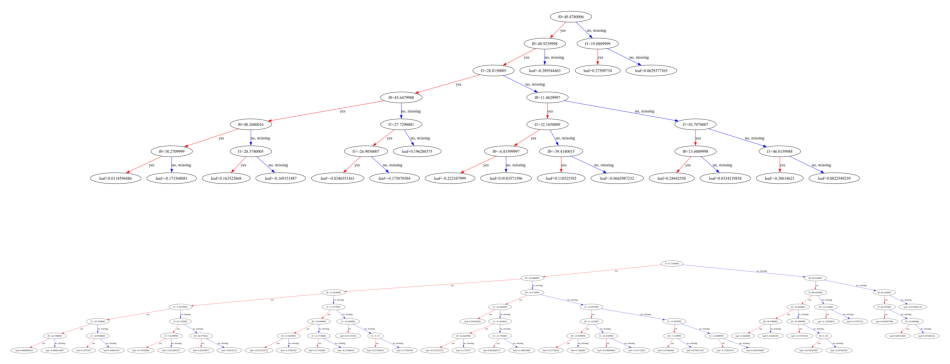

In [14]:
combinations_list = [(0,1,2,3), (0, 1), (0, 1, 3), (1, 2), (0, 2, 3), (2,3)]
x0 = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)

for comb in combinations_list:
    x = x0[:, comb]
    print(f"Combinazione colonne: {comb}")
    print(x.shape)
       
    y = y.astype(int)
    N,L = len(x), len(x[0])

    N_train = int(0.75*N)
    x_train,y_train = x[:N_train],y[:N_train]
    x_val,y_val = x[N_train:],y[N_train:]
    
    model = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain")

    classify(model, show=True)

We tested different subsets of features (L’ < L) by selecting combinations of the original 4 features using XGBoost as classifier.
In particular, we compared models trained on:

only the most significant features
combinations including less informative (noisy) features

From the results obtained with the different feature combinations, we observed that:

Using only the most relevant features (e.g. feature 0 and 1) provides the highest validation accuracy
Adding one noisy feature generally degrades performance, likely due to increased variance and overfitting to irrelevant patterns
Adding more noisy features can lead to a partial recovery in accuracy, suggesting that XGBoost is able to down-weight less informative features through its tree-based structure
When using only one relevant feature, or only noisy features, the accuracy drops significantly, indicating that the model is no longer able to extract meaningful information and is effectively performing close to random guessing

Overall, excluding the least important features leads to equal or better performance, indicating that dimensionality reduction is beneficial for this dataset.

This behavior shows that XGBoost is relatively robust to irrelevant features, but still benefits from feature selection, which effectively acts as a form of implicit regularization by reducing noise in the input space.
These results are consistent with the feature importance analysis, which highlights that only a subset of features contributes significantly to the model predictions.

## 3. XGBoost vs NN

In [15]:
sizes = [5000, 4000, 3000, 2000, 1000, 500]

np.random.seed(12345)
base_idx = np.random.permutation(5000)
combinations_list = [base_idx[:s] for s in sizes]

x0 = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y0 = np.loadtxt(fnamey)

acc_xgb_single = []
acc_nn_single = []

acc_xgboost = []
acc_ffnn = []

for comb in combinations_list:
    x = x0[comb,:] 
    y = y0[comb].astype(int)
    N,L = len(x), len(x[0])

    N_train = int(0.75*N)
    x_train,y_train = x[:N_train],y[:N_train]
    x_val,y_val = x[N_train:],y[N_train:]
    
    # XGBoost SINGLE 
    model_boost = XGBClassifier(
        seed=1,
        objective='binary:logistic',
        n_estimators=15,
        max_depth=5
    )
    
    model_boost.fit(x_train, y_train)
    acc_xgb0=model_boost.score(x_val, y_val)
    acc_xgb_single.append(acc_xgb0) 

    
    # FFNN SINGLE
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    
    model_ffnn = Sequential([
        Dense(32, activation='relu', input_shape=(L,)),
        Dense(16, activation='relu'),
        Dropout(0.1),
        Dense(8, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])

    model_ffnn.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model_ffnn.fit(x_train, y_train,epochs=200,batch_size=16,verbose=0)
    loss, acc_nn0 = model_ffnn.evaluate(x_val, y_val, verbose=0)
    acc_nn_single.append(acc_nn0)


    # KFOLD
    kf = KFold(n_splits=5, shuffle=True, random_state=1)

    # XGBoost KFold    
    acc_list_xgb = []
    for train_index, val_index in kf.split(x):
        x_tr, x_vl = x[train_index], x[val_index]
        y_tr, y_vl = y[train_index], y[val_index]

        model_boost = XGBClassifier(
            seed=1,
            objective='binary:logistic',
            n_estimators=15,
            max_depth=5
        )

        model_boost.fit(x_tr, y_tr)
        acc_list_xgb.append(model_boost.score(x_vl, y_vl))

    acc_xgb = np.mean(acc_list_xgb)
    acc_xgboost.append(acc_xgb)
    
    
    # FFNN KFold 
    acc_list_nn = []
    for train_index, val_index in kf.split(x):
        x_tr, x_vl = x[train_index], x[val_index]
        y_tr, y_vl = y[train_index], y[val_index]

        scaler = StandardScaler()
        x_tr = scaler.fit_transform(x_tr)
        x_vl = scaler.transform(x_vl)
        
        model_ffnn = Sequential([
            Dense(32, activation='relu', input_shape=(L,)),
            Dense(16, activation='relu'),
            Dropout(0.1),
            Dense(8, activation='relu'),
            Dropout(0.1),
            Dense(1, activation='sigmoid')
        ])

        model_ffnn.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        model_ffnn.fit(x_tr, y_tr, epochs=200, batch_size=16, verbose=0)
        loss, acc = model_ffnn.evaluate(x_vl, y_vl, verbose=0)
        acc_list_nn.append(acc)

    acc_nn = np.mean(acc_list_nn)
    acc_ffnn.append(acc_nn)
    
    print(f'           MODEL OF SIZE {x.shape} \n ')
    print("\n Results before K-FOLD ")
    print(f"XGBoost single Accuracy: {acc_xgb0:.3f}")
    print(f"FFNN    single Accuracy: {acc_nn0:.3f}")
    print("\n Results after K-FOLD ")
    print(f"XGBoost KFold Accuracy: {acc_xgb:.3f}")
    print(f"FFNN    KFold Accuracy: {acc_nn:.3f} \n \n \n ")

/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(

           MODEL OF SIZE (5000, 4) 
 

 Results before K-FOLD 
XGBoost single Accuracy: 0.876
FFNN    single Accuracy: 0.846

 Results after K-FOLD 
XGBoost KFold Accuracy: 0.877
FFNN    KFold Accuracy: 0.881 
 
 
 


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(

           MODEL OF SIZE (4000, 4) 
 

 Results before K-FOLD 
XGBoost single Accuracy: 0.861
FFNN    single Accuracy: 0.823

 Results after K-FOLD 
XGBoost KFold Accuracy: 0.871
FFNN    KFold Accuracy: 0.846 
 
 
 


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(

...

           MODEL OF SIZE (2000, 4) 
 

 Results before K-FOLD 
XGBoost single Accuracy: 0.830
FFNN    single Accuracy: 0.564

 Results after K-FOLD 
XGBoost KFold Accuracy: 0.819
FFNN    KFold Accuracy: 0.613 
 
 
 


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(

           MODEL OF SIZE (1000, 4) 
 

 Results before K-FOLD 
XGBoost single Accuracy: 0.752
FFNN    single Accuracy: 0.504

 Results after K-FOLD 
XGBoost KFold Accuracy: 0.740
FFNN    KFold Accuracy: 0.531 
 
 
 


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(

           MODEL OF SIZE (500, 4) 
 

 Results before K-FOLD 
XGBoost single Accuracy: 0.616
FFNN    single Accuracy: 0.544

 Results after K-FOLD 
XGBoost KFold Accuracy: 0.618
FFNN    KFold Accuracy: 0.472 
 
 
 


In the comparison between XGBoost and a feed-forward neural network (FFNN) on the generated dataset, XGBoost clearly outperforms the neural network both when reducing the training set size and when using all 5000 samples. This behavior is mainly due to the nature of the data: the target function is a step-like nonlinear function that depends only on the first two features, which is ideally suited for tree-based models like XGBoost. The neural network, while flexible, tends to produce smooth continuous approximations and suffers from underfitting even on the full dataset, especially with a small number of layers and neurons.


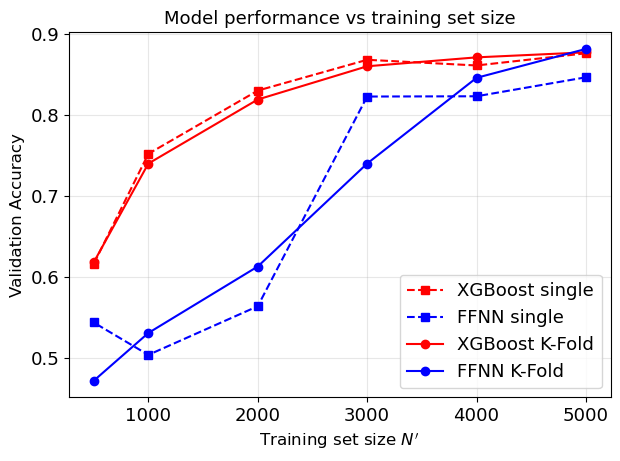

In [16]:
n= [5000, 4000, 3000, 2000, 1000, 500]

plt.plot(n, acc_xgb_single, marker='s', linestyle='--', color='red', label='XGBoost single')
plt.plot(n, acc_nn_single, marker='s', linestyle='--', color='blue', label='FFNN single')
plt.plot(n, acc_xgboost, marker='o', linestyle='-', color='red', label='XGBoost K-Fold')
plt.plot(n, acc_ffnn, marker='o', linestyle='-', color='blue', label='FFNN K-Fold')

plt.legend()
plt.xlabel('Training set size $N\'$', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Model performance vs training set size', fontsize=13)
plt.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("accuracy_vs_N.png", dpi=300)
plt.show()

It’s clear that XGBoost performs reasonably well even with small sample sizes *n*, while the neural network shows very low accuracy. It may even appear to improve as *n* decreases, but this is misleading—in reality, it is behaving almost randomly, since the sample sizes are far too small to train the model reliably.

/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


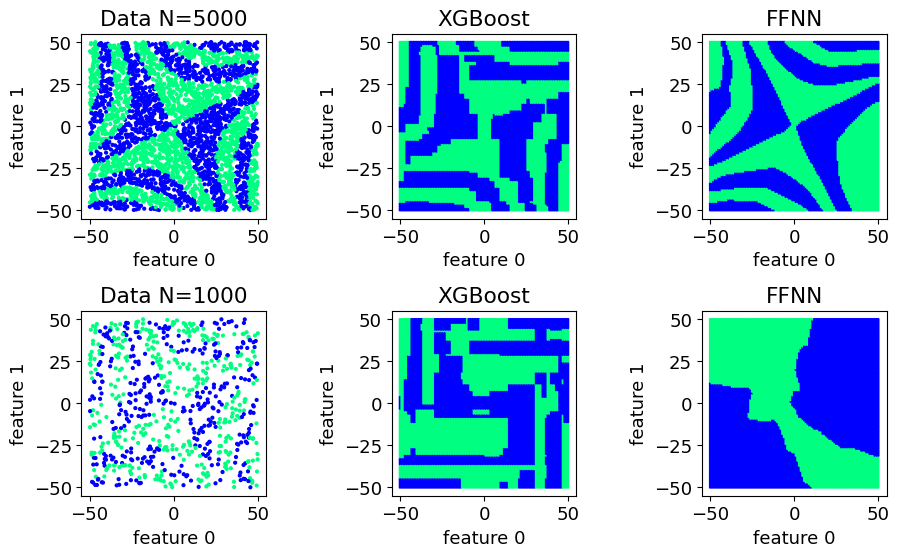

In [17]:
selected_sizes = [5000, 1000]
sizes = [5000, 4000, 3000, 2000, 1000, 500]

np.random.seed(12345)
base_idx = np.random.permutation(5000)
combinations_dict = {s: base_idx[:s] for s in sizes}

x0 = np.loadtxt(fnamex, delimiter=" ", dtype=float)
y0 = np.loadtxt(fnamey)

fig, AX = plt.subplots(len(selected_sizes),3,figsize=(12, 3*len(selected_sizes)))

if len(selected_sizes) == 1:
    AX = np.array([AX])

# LOOP ONLY ON SELECTED SIZES
for row, Nsel in enumerate(selected_sizes):

    comb = combinations_dict[Nsel]

        # DATASET
    x = x0[comb, :]
    y = y0[comb].astype(int)

    N, L = x.shape
    N_train = int(0.75 * N)

    x_train, y_train = x[:N_train], y[:N_train]
    x_val, y_val = x[N_train:], y[N_train:]

    # XGBOOST
    model_xgb = XGBClassifier(seed=1,
        objective='binary:logistic',
        n_estimators=15,
        max_depth=5)

    model_xgb.fit(x_train, y_train)

    acc_xgb = model_xgb.score(x_val, y_val)

    # FFNN
    scaler = StandardScaler()

    x_train_nn = scaler.fit_transform(x_train)
    x_val_nn = scaler.transform(x_val)

    model_ffnn = Sequential([
        Dense(32, activation='relu', input_shape=(L,)),
        Dense(16, activation='relu'),
        Dropout(0.1),
        Dense(8, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')])

    model_ffnn.compile(optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy'])

    model_ffnn.fit(x_train_nn,y_train,epochs=200,batch_size=16,verbose=0)
    loss, acc_ffnn = model_ffnn.evaluate(x_val_nn,y_val,verbose=0)

    
    # GRID
    S = 50
    dx = 1

    x_seq = np.arange(-S, S + dx, dx)
    nx = len(x_seq)

    x_plot = np.zeros((nx * nx, L))

    q = 0
    for i in range(nx):
        for j in range(nx):
            x_plot[q, :2] = [x_seq[i], x_seq[j]]
            q += 1

    # PREDICTIONS
    y_plot_xgb = model_xgb.predict(x_plot)

    x_plot_nn = scaler.transform(x_plot)
    y_plot_ffnn = model_ffnn.predict(x_plot_nn, verbose=0)
    y_plot_ffnn = (y_plot_ffnn > 0.5).astype(int)

    # PLOTS
    scat(AX[row, 0],x_train,y_train,title=f"Data N={N}")
    scat(AX[row, 1],x_plot,y_plot_xgb,s=dx,title=f"XGBoost")
    scat(AX[row, 2],x_plot,y_plot_ffnn,s=dx,title=f"FFNN")
    
    AX[row, 0].set_box_aspect(1)
    AX[row, 1].set_box_aspect(1)
    AX[row, 2].set_box_aspect(1)

plt.subplots_adjust(wspace=0.002, hspace=0.5)
#plt.savefig("data_XGB_NN.png", dpi=300)
plt.show()